# Prédiction du Churn Client — Telco Customer Churn

**Auteur(s) :** _(à compléter)_
**Module :** Machine Learning — M. Abdallah Khemais

## 1. Contexte et problématique

Une entreprise de télécommunications souhaite identifier à l'avance les clients susceptibles de **résilier leur abonnement (churn)**, afin de pouvoir agir en amont (offre de fidélisation, contact proactif...). On formule cela comme un problème de **classification binaire supervisée** : à partir des caractéristiques d'un client (ancienneté, services souscrits, type de contrat, facturation...), prédire s'il va churner (1) ou rester (0).

## 2. Le dataset

- **Source :** dataset publié initialement par IBM, largement utilisé en recherche et en formation (référencé sur Kaggle sous le nom *Telco Customer Churn*, par l'utilisateur blastchar)
- **Justification du choix (source externe) :** dataset propre, taille suffisante (7043 lignes, 21 variables), problématique métier claire et pertinente (rétention client), absent des sources locales tunisiennes recommandées en priorité
- **Volume :** 7043 clients, 21 variables (20 explicatives + 1 cible `Churn`)
- **Type de variables :** mix de variables numériques (ancienneté, facturation) et catégorielles (services, type de contrat, mode de paiement...)

## 3. Méthodologie

EDA → Prétraitement (nettoyage, encodage, scaling) → Comparaison de 4 modèles → Optimisation du meilleur (GridSearchCV) → Évaluation → Sauvegarde

---
## 1. Import des bibliothèques et chargement robuste des données

Cette cellule fonctionne automatiquement que tu sois sur Google Colab (fichier à la racine) ou en local avec la structure de dossiers complète (`data/raw/...`) — elle cherche le fichier aux emplacements les plus probables.

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


def find_file(filename, search_dirs=None):
    """Cherche le fichier dans les emplacements les plus probables
    (racine Colab, dossier data/raw local, etc.) pour éviter les erreurs
    de chemin selon l'environnement d'exécution."""
    if search_dirs is None:
        search_dirs = ['.', 'data/raw', '../data/raw', 'data', '..']
    for d in search_dirs:
        candidate = os.path.join(d, filename)
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError(
        f"Impossible de trouver '{filename}'. "
        f"Uploade-le dans le panneau Fichiers (Colab) ou place-le dans data/raw/ (local)."
    )


def save_here(obj, filename, is_dataframe=False):
    """Sauvegarde toujours dans le dossier courant — fonctionne
    pareil sur Colab et en local, aucun chemin à corriger."""
    if is_dataframe:
        obj.to_csv(filename, index=False)
    else:
        joblib.dump(obj, filename)
    print(f"Sauvegardé : {filename}")

## 2. Chargement des données

In [2]:
csv_path = find_file("Telco-Customer-Churn.csv")
df = pd.read_csv(csv_path)
print(f"Fichier trouvé : {csv_path}")
print(df.shape)
df.head()

Fichier trouvé : ../data/raw/Telco-Customer-Churn.csv
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Analyse exploratoire (synthèse)

_Détail complet disponible dans `01_EDA_draft.ipynb`. On reprend ici les observations clés._

/tmp/ipykernel_574/4089913037.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2', ax=axes[0])


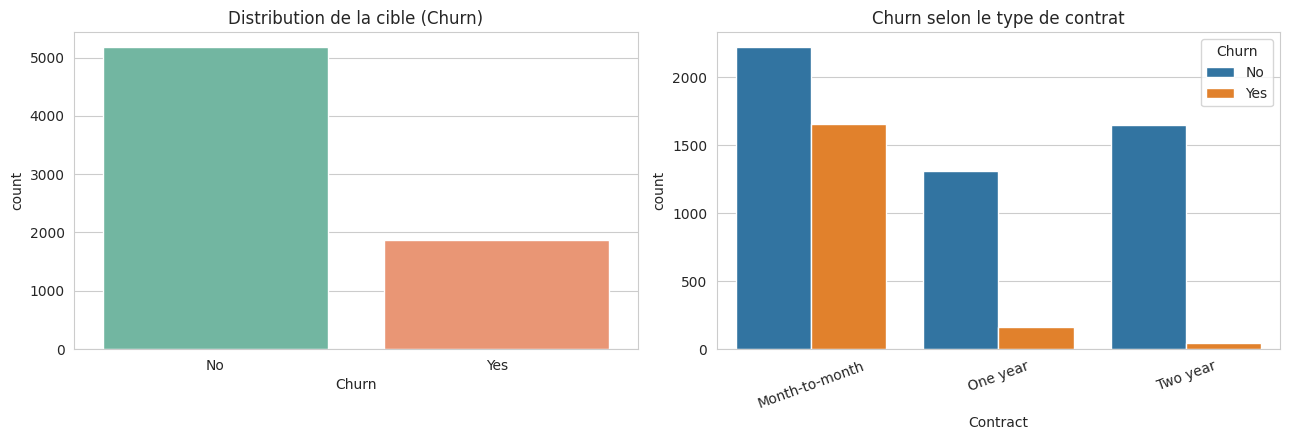

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x='Churn', palette='Set2', ax=axes[0])
axes[0].set_title("Distribution de la cible (Churn)")

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1])
axes[1].set_title("Churn selon le type de contrat")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("eda_summary.png", dpi=120, bbox_inches='tight')
plt.show()

print(df['Churn'].value_counts(normalize=True).round(3))

**Observations clés :**
- Classes déséquilibrées : ~26.5% de churn vs ~73.5% de clients fidèles -> impose le choix du **F1-score** plutôt que la seule Accuracy comme métrique de comparaison
- Les clients en contrat **"Month-to-month"** résilient beaucoup plus que ceux engagés sur 1 ou 2 ans -> variable `Contract` probablement très prédictive
- `tenure` (ancienneté) est négativement corrélée au churn ; `MonthlyCharges` y est positivement corrélée

## 4. Prétraitement

In [4]:
df = df.drop(columns=['customerID'])

# 11 valeurs manquantes sur TotalCharges = clients avec tenure=0 (nouveaux, pas encore facturés)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X = df.drop(columns=['Churn'])
y = df['Churn']
cat_cols = X.select_dtypes(include='object').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Train :", X_train_proc.shape, " Test :", X_test_proc.shape)

Train : (5634, 29)  Test : (1409, 29)


/tmp/ipykernel_574/965883571.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


**Décisions de prétraitement (rappel des choix faits en détail dans `02_preprocessing_draft.ipynb`) :**
- Suppression de `customerID` (identifiant sans valeur prédictive)
- `TotalCharges` manquant → remplacé par 0 (logique : ces clients ont `tenure = 0`)
- Encodage cible binaire (0 = reste, 1 = churn)
- Aucun outlier significatif détecté (méthode IQR) → aucun traitement nécessaire
- `StandardScaler` (numérique) + `OneHotEncoder` (catégoriel), **fit uniquement sur le train** pour éviter le data leakage

## 5. Modélisation — comparaison de 4 algorithmes

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)
results_df.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
Gradient Boosting,0.806,0.662,0.545,0.598,0.842
Logistic Regression,0.801,0.647,0.553,0.597,0.841
SVM,0.796,0.657,0.481,0.556,0.798
Random Forest,0.780,0.609,0.479,0.536,0.821


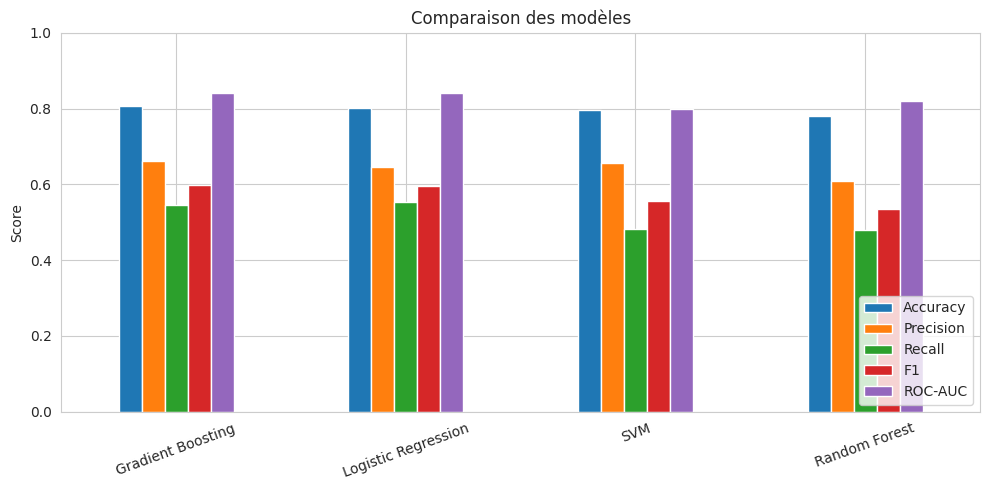

In [6]:
results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 5), ylim=(0, 1)
)
plt.title("Comparaison des modèles")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("models_comparison.png", dpi=120, bbox_inches='tight')
plt.show()

**Pourquoi comparer plusieurs modèles ?** Chacun a une logique différente : Logistic Regression (linéaire, simple, interprétable), Random Forest et Gradient Boosting (ensemblistes, basés sur des arbres), SVM (recherche de marge maximale). On ne sait jamais à l'avance lequel s'adapte le mieux à la structure des données — d'où la comparaison systématique plutôt qu'un choix a priori.

**Pourquoi classer par F1-score plutôt que par Accuracy ?** Rappel : classes déséquilibrées (vu en EDA). Un modèle qui prédirait toujours "pas de churn" aurait déjà ~73% d'Accuracy sans rien apprendre d'utile. Le F1-score (moyenne harmonique de Precision et Recall) pénalise ce genre de raccourci.

## 6. Optimisation du meilleur modèle (GridSearchCV)

In [7]:
best_model_name = results_df.index[0]
print("Meilleur modèle avant optimisation :", best_model_name)

# Grilles d'hyperparamètres adaptées à chaque type de modèle
param_grids = {
    "Logistic Regression": {"C": [0.01, 0.1, 1, 10]},
    "Random Forest": {"n_estimators": [100, 200], "max_depth": [5, 10, None], "min_samples_split": [2, 5]},
    "Gradient Boosting": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]},
    "SVM": {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]}
}

# On optimise le modèle qui a réellement gagné, pas un modèle fixé d'avance
grid = GridSearchCV(
    models[best_model_name],
    param_grids[best_model_name],
    cv=5, scoring="f1", n_jobs=-1
)
grid.fit(X_train_proc, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur F1 (validation croisée, 5-fold) :", round(grid.best_score_, 3))

best_model = grid.best_estimator_

Meilleur modèle avant optimisation : Gradient Boosting


Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Meilleur F1 (validation croisée, 5-fold) : 0.575


## 7. Évaluation finale

In [8]:
y_pred_final = best_model.predict(X_test_proc)
y_proba_final = best_model.predict_proba(X_test_proc)[:, 1]

print(classification_report(y_test, y_pred_final, target_names=["Reste", "Churn"]))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba_final), 3))

              precision    recall  f1-score   support

       Reste       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC : 0.842


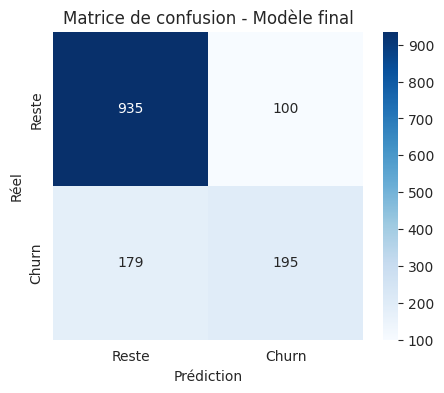

In [9]:
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Reste", "Churn"], yticklabels=["Reste", "Churn"])
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Modèle final")
plt.savefig("confusion_matrix_final.png", dpi=120, bbox_inches='tight')
plt.show()

**Lecture de la matrice de confusion :**
- Un **faux négatif** (client réellement churn, prédit "reste") est le plus coûteux pour l'entreprise : elle ne le contacte pas et le perd réellement
- Un **faux positif** (client prédit churn mais qui reste) coûte moins cher : au pire, une offre de fidélisation envoyée inutilement

### 7.1 Importance des variables

/tmp/ipykernel_574/3667699839.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


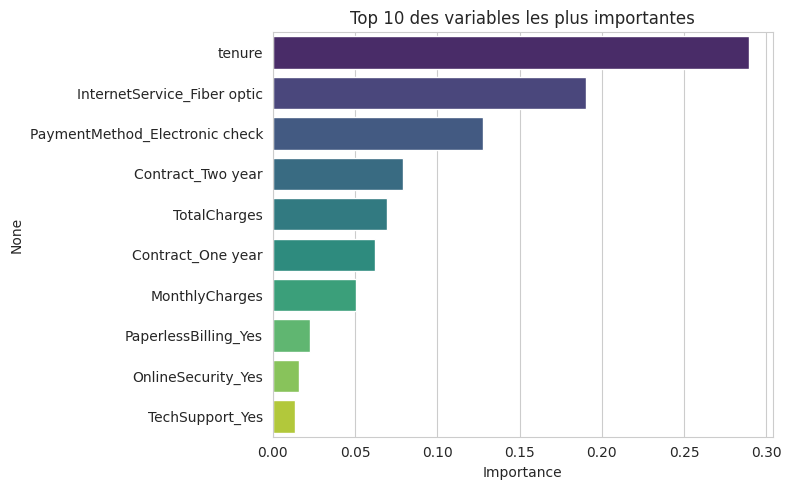

In [10]:
feature_names = (num_cols +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)))

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_names)
    title = "Top 10 des variables les plus importantes"
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=feature_names)
    title = "Top 10 des variables les plus influentes (|coefficient|)"
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=False).head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette='viridis')
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=120, bbox_inches='tight')
    plt.show()
else:
    print(f"{best_model_name} ne fournit pas d'importance de variables directement interprétable "
          f"(pas de feature_importances_ ni de coef_ exploitable ici).")

## 8. Sauvegarde

In [11]:
save_here(best_model, "best_model.pkl")
save_here(preprocessor, "preprocessor.pkl")

Sauvegardé : best_model.pkl
Sauvegardé : preprocessor.pkl


In [12]:
print(f"""
## 9. Conclusion

- Problème résolu : classification binaire pour prédire le churn client à partir de ses caractéristiques
- 4 modèles comparés (Logistic Regression, Random Forest, Gradient Boosting, SVM)
- Modèle retenu : {best_model_name}, optimisé via GridSearchCV (validation croisée 5-fold)
- F1-score (validation croisée) : {round(grid.best_score_, 3)}
- ROC-AUC (test) : {round(roc_auc_score(y_test, y_proba_final), 3)}

Variables les plus influentes : voir graphique ci-dessus (cohérent avec l'intuition métier :
ancienneté, type de contrat et facturation jouent un rôle clé dans la décision de résiliation).

Limites et perspectives :
- Le déséquilibre des classes pourrait être traité plus finement avec du rééquilibrage (SMOTE, class_weight)
- D'autres modèles (XGBoost, LightGBM) ou du feature engineering supplémentaire pourraient encore améliorer le F1-score
- Bonus envisagé : déploiement via une application Streamlit utilisant best_model.pkl et preprocessor.pkl
""")


## 9. Conclusion

- Problème résolu : classification binaire pour prédire le churn client à partir de ses caractéristiques
- 4 modèles comparés (Logistic Regression, Random Forest, Gradient Boosting, SVM)
- Modèle retenu : Gradient Boosting, optimisé via GridSearchCV (validation croisée 5-fold)
- F1-score (validation croisée) : 0.575
- ROC-AUC (test) : 0.842

Variables les plus influentes : voir graphique ci-dessus (cohérent avec l'intuition métier :
ancienneté, type de contrat et facturation jouent un rôle clé dans la décision de résiliation).

Limites et perspectives :
- Le déséquilibre des classes pourrait être traité plus finement avec du rééquilibrage (SMOTE, class_weight)
- D'autres modèles (XGBoost, LightGBM) ou du feature engineering supplémentaire pourraient encore améliorer le F1-score
- Bonus envisagé : déploiement via une application Streamlit utilisant best_model.pkl et preprocessor.pkl

